In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk")

WORK_DIR = "/kaggle/working"
DIR="/kaggle/input/datasets/katakuricharlotte/cleaned-cicid"
CLEAN_PATH = os.path.join(DIR, "cleaned_dataset.parquet")

df = pd.read_parquet(CLEAN_PATH)
print("Loaded cleaned dataset:", df.shape)
df.head()

Loaded cleaned dataset: (2313722, 79)


,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,attack_category
0,6,4,2,0,12,0,6,6,6.00000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,Benign,Normal
1,6,1,2,0,12,0,6,6,6.00000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,Benign,Normal
2,6,3,2,0,12,0,6,6,6.00000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,Benign,Normal
3,6,1,2,0,12,0,6,6,6.00000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,Benign,Normal
4,6,609,7,4,484,414,233,0,69.14286,111.967896,...,0.0,0.0,0,0,0.0,0.0,0,0,Benign,Normal


In [2]:
print("DataFrame info:")
df.info()

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("\nNumber of numeric columns:", len(numeric_cols))

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2313722 entries, 0 to 2313721
Data columns (total 79 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   Protocol                  int8   
 1   Flow Duration             int32  
 2   Total Fwd Packets         int32  
 3   Total Backward Packets    int32  
 4   Fwd Packets Length Total  int32  
 5   Bwd Packets Length Total  int32  
 6   Fwd Packet Length Max     int16  
 7   Fwd Packet Length Min     int16  
 8   Fwd Packet Length Mean    float32
 9   Fwd Packet Length Std     float32
 10  Bwd Packet Length Max     int16  
 11  Bwd Packet Length Min     int16  
 12  Bwd Packet Length Mean    float32
 13  Bwd Packet Length Std     float32
 14  Flow Bytes/s              float64
 15  Flow Packets/s            float64
 16  Flow IAT Mean             float32
 17  Flow IAT Std              float32
 18  Flow IAT Max              int32  
 19  Flow IAT Min              int32  
 20  Fwd IAT 

In [3]:
# We'll compute an approximate entropy over packet length distribution
# using Packet Length Min/Max/Mean/Std.

packet_len_cols = [
    "Packet Length Min",
    "Packet Length Max",
    "Packet Length Mean",
    "Packet Length Std",
]

for col in packet_len_cols:
    if col not in df.columns:
        print(f"Warning: {col} not in df.")

def approximate_flow_entropy(row, eps=1e-9):
    # construct a simple 4-bin distribution from basic stats
    vals = np.array([
        max(row["Packet Length Min"], 0),
        max(row["Packet Length Mean"] - row["Packet Length Std"], 0),
        max(row["Packet Length Mean"] + row["Packet Length Std"], 0),
        max(row["Packet Length Max"], 0),
    ], dtype=float)
    if np.any(np.isnan(vals)) or np.all(vals == 0):
        return 0.0
    probs = vals / (vals.sum() + eps)
    return -(probs * np.log2(probs + eps)).sum()

df["flow_entropy"] = df[packet_len_cols].apply(approximate_flow_entropy, axis=1)
df["flow_entropy"].describe()

count    2.313722e+06
mean     1.299918e+00
std      6.164252e-01
min      0.000000e+00
25%      8.993050e-01
50%      1.360964e+00
75%      1.873723e+00
max      2.000000e+00
Name: flow_entropy, dtype: float64

In [4]:
# Replace with actual column names if different
SRC_IP_COL = "Src IP"   # or "Source IP"
DST_IP_COL = "Dst IP"   # or "Destination IP"
SRC_PORT_COL = "Src Port"
DST_PORT_COL = "Dst Port"

missing_ip_cols = [c for c in [SRC_IP_COL, DST_IP_COL, SRC_PORT_COL, DST_PORT_COL] if c not in df.columns]
print("Missing IP/port cols:", missing_ip_cols)

Missing IP/port cols: ['Src IP', 'Dst IP', 'Src Port', 'Dst Port']


In [5]:
if not missing_ip_cols:
    # Unique destination IPs per source IP
    src_to_dst_unique = (
        df.groupby(SRC_IP_COL)[DST_IP_COL]
          .nunique()
          .rename("src_unique_dst_ip")
    )

    # Unique destination ports per source IP
    src_to_dst_ports_unique = (
        df.groupby(SRC_IP_COL)[DST_PORT_COL]
          .nunique()
          .rename("src_unique_dst_port")
    )

    df = df.join(src_to_dst_unique, on=SRC_IP_COL)
    df = df.join(src_to_dst_ports_unique, on=SRC_IP_COL)
else:
    # If you don't have IP/port columns in this parquet, set features to NaN
    df["src_unique_dst_ip"] = np.nan
    df["src_unique_dst_port"] = np.nan

df[["src_unique_dst_ip", "src_unique_dst_port"]].describe()

,src_unique_dst_ip,src_unique_dst_port
count,0.0,0.0
mean,NaN,NaN
std,NaN,NaN
min,NaN,NaN
25%,NaN,NaN
50%,NaN,NaN
75%,NaN,NaN
max,NaN,NaN


In [6]:
# Columns for temporal stats (CICIDS2017 standard names)
FLOW_DURATION_COL = "Flow Duration"
FLOW_IAT_MEAN_COL = "Flow IAT Mean"
FLOW_IAT_STD_COL = "Flow IAT Std"

for col in [FLOW_DURATION_COL, FLOW_IAT_MEAN_COL, FLOW_IAT_STD_COL]:
    if col not in df.columns:
        print("Missing temporal column:", col)

# Inter-arrival variance
df["flow_iat_var"] = df[FLOW_IAT_STD_COL] ** 2

# Burstiness: (sigma - mu) / (sigma + mu)
def compute_burstiness(row, eps=1e-9):
    mu = row[FLOW_IAT_MEAN_COL]
    sigma = row[FLOW_IAT_STD_COL]
    if mu < 0 or sigma < 0:
        return 0.0
    denom = sigma + mu + eps
    return (sigma - mu) / denom

df["flow_burstiness"] = df[[FLOW_IAT_MEAN_COL, FLOW_IAT_STD_COL]].apply(compute_burstiness, axis=1)
df[["flow_iat_var", "flow_burstiness"]].describe()

,flow_iat_var,flow_burstiness
count,2.313722e+06,2.313722e+06
mean,8.962539e+13,-2.297986e-02
std,3.363358e+14,5.872287e-01
min,0.000000e+00,-1.000000e+00
25%,4.500000e+00,-5.851180e-01
50%,3.035139e+08,2.487185e-01
75%,3.611890e+12,3.576855e-01
max,7.191085e+15,9.935450e-01


In [7]:
from scipy.stats import skew, kurtosis

# Pick a small, meaningful subset of numeric features for per-flow stats
stat_feature_group = [
    "Total Fwd Packets",
    "Total Backward Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Packet Length Mean",
    "Packet Length Std",
]

missing_stat_cols = [c for c in stat_feature_group if c not in df.columns]
print("Missing stat cols:", missing_stat_cols)

Missing stat cols: []


In [8]:
def row_skewness(row):
    vals = row.values.astype(float)
    if np.any(np.isnan(vals)):
        vals = vals[~np.isnan(vals)]
    if len(vals) < 3:
        return 0.0
    return float(skew(vals, bias=False))

def row_kurtosis(row):
    vals = row.values.astype(float)
    if np.any(np.isnan(vals)):
        vals = vals[~np.isnan(vals)]
    if len(vals) < 4:
        return 0.0
    return float(kurtosis(vals, fisher=True, bias=False))

df["flow_stat_skewness"] = df[stat_feature_group].apply(row_skewness, axis=1)
df["flow_stat_kurtosis"] = df[stat_feature_group].apply(row_kurtosis, axis=1)

df[["flow_stat_skewness", "flow_stat_kurtosis"]].describe()

,flow_stat_skewness,flow_stat_kurtosis
count,2.313722e+06,2.313722e+06
mean,2.045052e+00,4.303862e+00
std,6.596778e-01,2.638986e+00
min,-2.190678e+00,-3.333328e+00
25%,1.777304e+00,3.094610e+00
50%,2.440714e+00,5.966126e+00
75%,2.448352e+00,5.995645e+00
max,2.449490e+00,6.000000e+00


In [9]:
engineered_cols = [
    "flow_entropy",
    "flow_iat_var",
    "flow_burstiness",
    "flow_stat_skewness",
    "flow_stat_kurtosis",
    "src_unique_dst_ip",
    "src_unique_dst_port",
]

all_feature_cols = [c for c in numeric_cols] + engineered_cols
all_feature_cols = [c for c in all_feature_cols if c in df.columns]

print("Total feature columns (including engineered):", len(all_feature_cols))

Total feature columns (including engineered): 84


In [10]:
target_col = "attack_category"
le = LabelEncoder()
y = le.fit_transform(df[target_col])

# For MI, work on a sample to keep runtime manageable
MI_SAMPLE_SIZE = 500_000
if len(df) > MI_SAMPLE_SIZE:
    df_mi = df.sample(MI_SAMPLE_SIZE, random_state=42)
else:
    df_mi = df.copy()

X_mi = df_mi[all_feature_cols].fillna(0).astype(float)
y_mi = le.transform(df_mi[target_col])

mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42)
mi_series = pd.Series(mi_scores, index=all_feature_cols).sort_values(ascending=False)

mi_series.head(30)

Avg Packet Size             0.368927
Packet Length Mean          0.336137
flow_entropy                0.311610
Packet Length Std           0.308674
Packet Length Variance      0.305158
Bwd Packets Length Total    0.298332
Subflow Bwd Bytes           0.297367
Bwd Packet Length Mean      0.291050
Avg Bwd Segment Size        0.290140
Subflow Fwd Bytes           0.289868
Fwd Packets Length Total    0.289546
Packet Length Max           0.287351
Fwd Packet Length Mean      0.271914
Avg Fwd Segment Size        0.271175
Fwd Packet Length Max       0.269051
Bwd Packet Length Std       0.260012
Flow IAT Max                0.257800
Fwd IAT Max                 0.250961
Fwd Packet Length Std       0.248591
Bwd Packet Length Max       0.248146
Fwd IAT Total               0.240129
Init Bwd Win Bytes          0.232239
Init Fwd Win Bytes          0.224802
Bwd IAT Max                 0.199872
Flow Duration               0.191388
Idle Max                    0.187178
Bwd IAT Total               0.181967
f

/tmp/ipykernel_17/2137629389.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


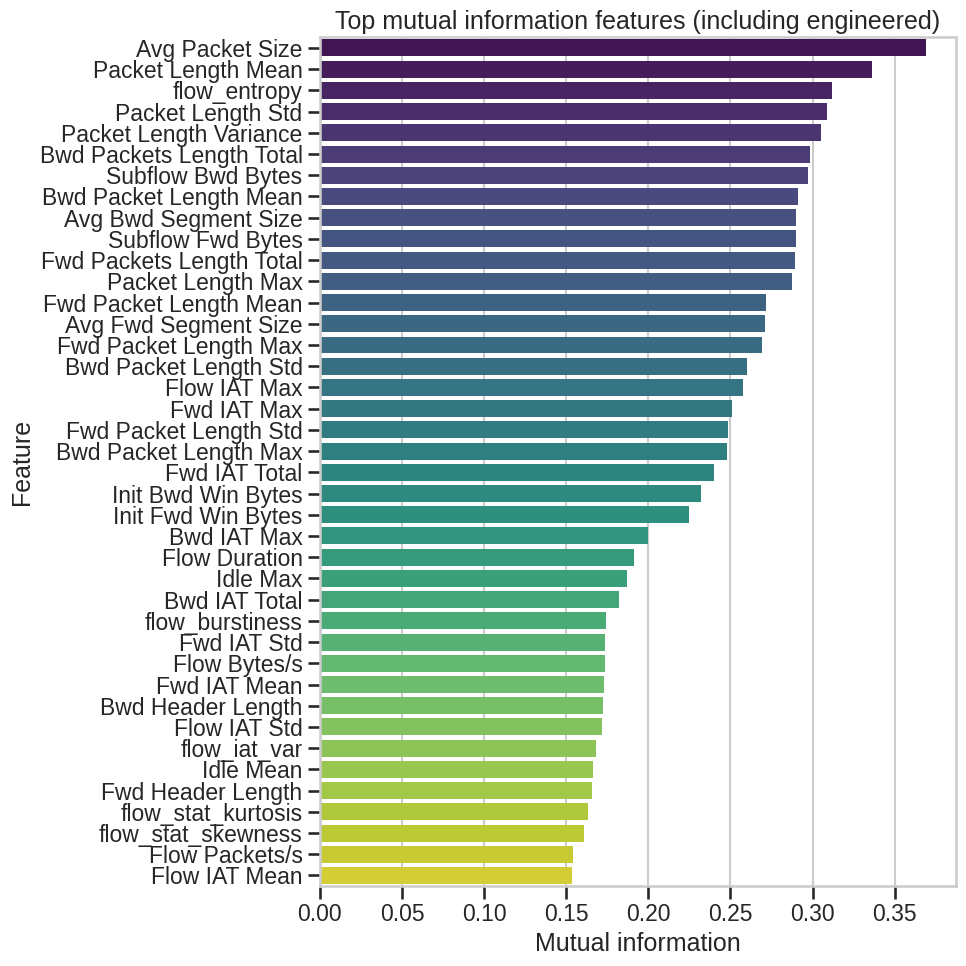

In [11]:
TOP_K_MI = 40

plt.figure(figsize=(10, 10))
sns.barplot(
    x=mi_series.head(TOP_K_MI),
    y=mi_series.head(TOP_K_MI).index,
    palette="viridis"
)
plt.title("Top mutual information features (including engineered)")
plt.xlabel("Mutual information")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("mi_feature_ranking_with_engineered.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
mi_series.to_frame(name="mutual_information").reset_index().rename(columns={"index": "feature"}) \
         .to_csv("feature_ranking_mi.csv", index=False)

In [13]:
# Placeholder: XGBoost feature importance will be computed in 04_Baseline_ML.ipynb
# using the same all_feature_cols list and then exported as xgboost_feature_importance.csv

# Placeholder: SHAP values will be computed for the best tree-based model
# and aggregated per feature into shap_feature_importance.csv

In [14]:
TOP_SELECTED = 60  # adjust as needed based on MI curve

selected_features = mi_series.head(TOP_SELECTED).index.tolist()
len(selected_features), selected_features[:10]

(60,
 ['Avg Packet Size',
  'Packet Length Mean',
  'flow_entropy',
  'Packet Length Std',
  'Packet Length Variance',
  'Bwd Packets Length Total',
  'Subflow Bwd Bytes',
  'Bwd Packet Length Mean',
  'Avg Bwd Segment Size',
  'Subflow Fwd Bytes'])

In [15]:
df_selected = df[selected_features + [target_col]]
df_selected.to_parquet(os.path.join(WORK_DIR, "selected_features.parquet"), index=False)
print("Saved selected_features.parquet with shape:", df_selected.shape)

Saved selected_features.parquet with shape: (2313722, 61)


In [16]:
pd.Series(selected_features, name="feature").to_csv("selected_feature_list.csv", index=False)